# Introduction

In this notebook, we perform an analysis of the external DLLs and functions found within our dataset of malicious and benign windows executables. We consider the pairwise similarity of these binaries, visualise our dataset, and explore the characteristics of both executable class in order to guide out later experiments. 

In [1]:
import utils
from os import PathLike
from collections import Counter
from typing import List
import pefile
import numpy as np
from tqdm import tqdm
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS, TSNE
from sklearn.decomposition import PCA
import pandas as pd


mpl.rcParams["figure.dpi"] = 300

PERFORM_EXTRACTION = False
SHUFFLE = True
N = 10

In [ ]:
def find_most_similar(similarity_matrix: np.ndarray, n: int = N):
    m, p = similarity_matrix.shape

    assert m == p, "Similarity matrix should be square"

    upper_triangle_indices = np.triu_indices(m, k=1)
    upper_triangle_values = similarity_matrix[upper_triangle_indices]
    top_n_indices = np.argpartition(upper_triangle_values, -n)[-n:]
    top_n_sorted_indices = top_n_indices[
        np.argsort(upper_triangle_values[top_n_indices])[::-1]
    ]
    return np.array(
        [
            (upper_triangle_indices[0][i], upper_triangle_indices[1][i])
            for i in top_n_sorted_indices
        ]
    )


def get_imports(executable_path: PathLike) -> List[str]:
    try:
        pe = pefile.PE(executable_path, fast_load=True)
        pe.parse_data_directories()
        return [
            symb.name.decode("ascii")
            for entry in pe.DIRECTORY_ENTRY_IMPORT
            for symb in entry.imports
            if symb.name is not None
        ]
    except:
        return []


def get_dlls(executable_path: PathLike) -> List[str]:
    try:
        pe = pefile.PE(executable_path)
        pe.DIRECTORY_ENTRY_IMPORT
        return [entry.dll.decode("ascii") for entry in pe.DIRECTORY_ENTRY_IMPORT]
    except:
        return []


dataset = utils.data.MalwareDataset()
labels = np.array([label for _, label in dataset])
programs = np.array([path.split("/")[-1] for path, _ in dataset])

n_mal = np.count_nonzero(labels)
n_ben = len(dataset) - n_mal

# Function Analysis

We begin by analysing external functions used by each of the executables, extracted using the `pefile` python module. External functions which are only seen once across our dataset are removed for performance reasons.

## Feature Extraction

In [3]:
if PERFORM_EXTRACTION:
    imports = {
        "malicious": {},
        "benign": {},
    }
    for path, label in tqdm(dataset, total=len(dataset)):
        exec_imports = get_imports(path)
        imports["malicious" if label == 1 else "benign"][path.split("/")[-1]] = (
            exec_imports
        )
    json.dump(imports, open("dataset-imports.json", "w"))
else:
    imports = json.loads(open("dataset-imports.json", "r").read())

In [4]:
fn_usage = Counter(
    [fn for cat in imports for dll in imports[cat].values() for fn in dll]
)

In [5]:
fn_usage_np = np.array(list(fn_usage.values()))
only_seek_once = set(np.array(list(fn_usage.keys()))[fn_usage_np == 1])
print(
    f"{100 * (len(only_seek_once) / len(fn_usage)):.2f}% of functions are only seen once"
)

54.03% of functions are only seen once

In [6]:
common_fns = {k: v for k, v in fn_usage.items() if v > 1}
fn_matrix = np.zeros((len(dataset), len(common_fns)))
fns_used = list(common_fns.keys())

M, N = fn_matrix.shape
loop = tqdm(total=M * N, desc="Generating Matrix", leave=False)

for i, (path, label) in enumerate(dataset):
    if label == 1:
        fns = imports["malicious"][path.split("/")[-1]]
    else:
        fns = imports["benign"][path.split("/")[-1]]

    for j, fn in enumerate(fns_used):
        loop.update(1)
        if fn in fns:
            fn_matrix[i, j] = 1

Generating Matrix: 100%|█████████▉| 388681955/388747125 [04:50<00:00, 1654836.16it/s]

In [7]:
fn_matrix_processed = fn_matrix.copy()

if SHUFFLE:
    np.random.shuffle(fn_matrix_processed[:n_mal])
    np.random.shuffle(fn_matrix_processed[n_mal:])

## Similarity 

In [8]:
fn_sim = cosine_similarity(fn_matrix_processed)

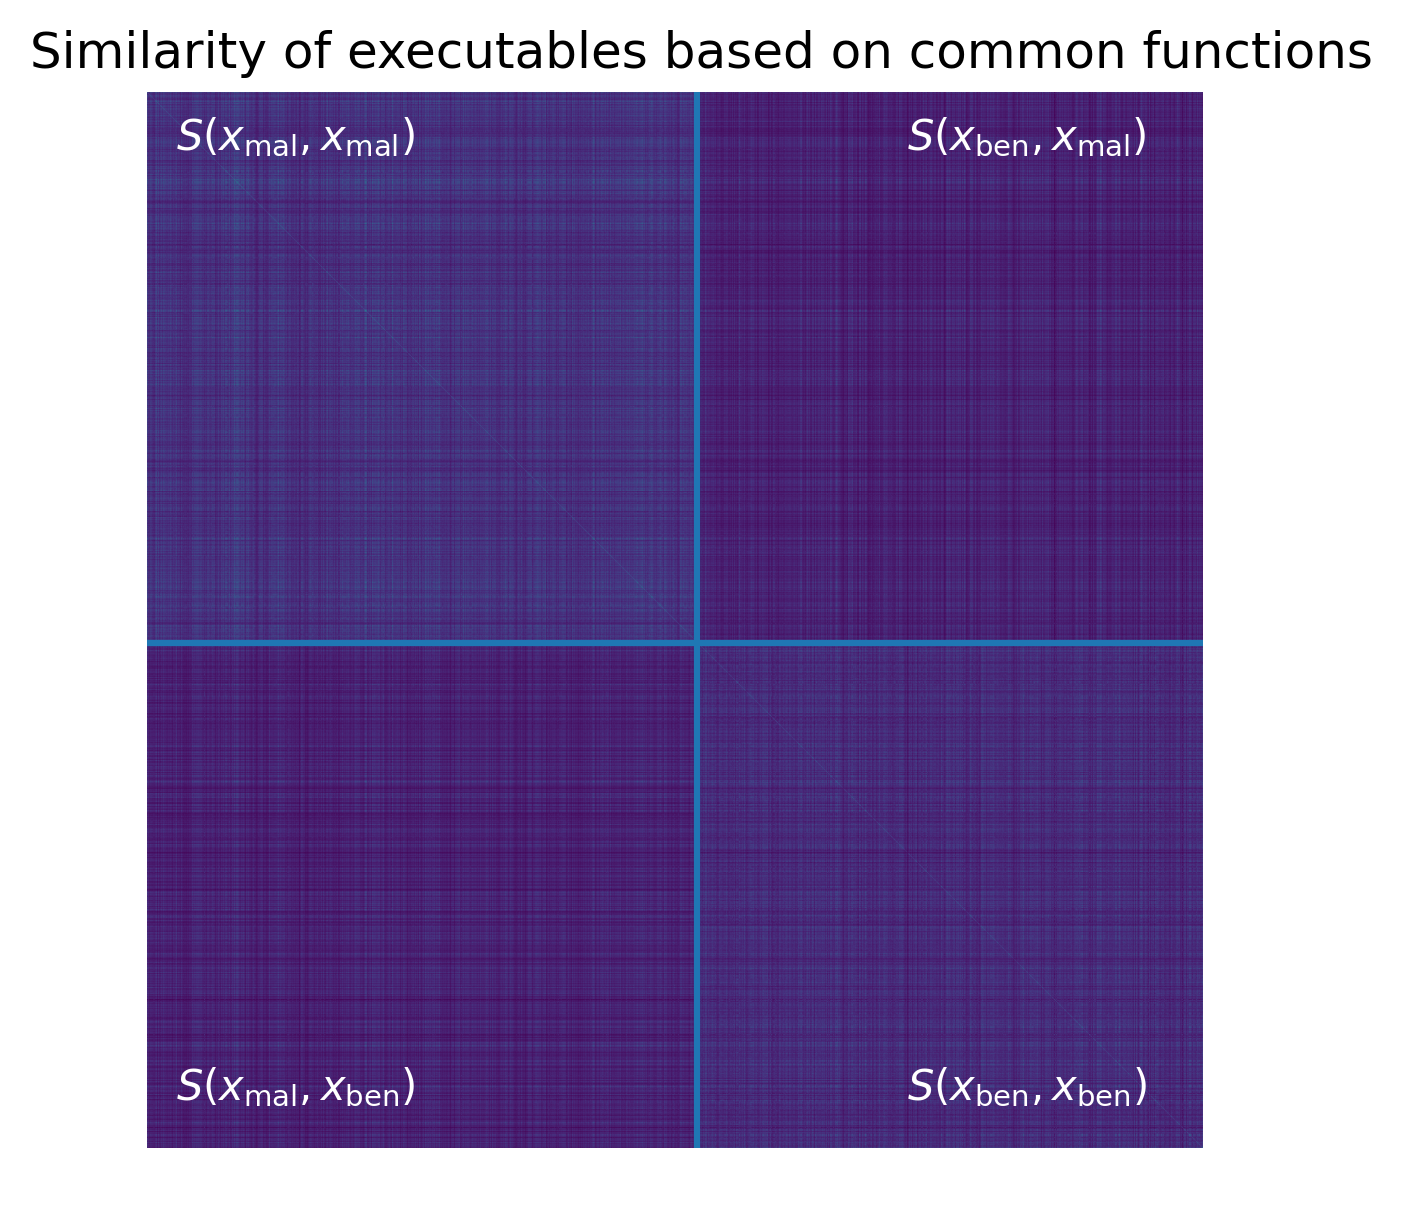

In [39]:
plt.imshow(fn_sim)
plt.axis("off")
plt.title("Similarity of executables based on common functions")
plt.hlines(np.count_nonzero(labels), 0, len(dataset))
plt.vlines(np.count_nonzero(labels), 0, len(dataset))
plt.text(300, 600, r"$S(x_\text{mal}, x_\text{mal})$", c="white")
plt.text(300, 10600, r"$S(x_\text{mal}, x_\text{ben})$", c="white")
plt.text(8000, 10600, r"$S(x_\text{ben}, x_\text{ben})$", c="white")
plt.text(8000, 600, r"$S(x_\text{ben}, x_\text{mal})$", c="white")
plt.show()

In [10]:
most_similar = find_most_similar(fn_sim)
sim = fn_sim[most_similar[:, 0], most_similar[:, 1]]

df = pd.DataFrame(
    {
        ("Similarity", ""): sim,
        ("Programs", "1"): programs[most_similar][:, 0],
        ("Programs", "2"): programs[most_similar][:, 1],
    }
)
df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Similarity                                     Programs  \
                                                        1   
0        1.0  VirusShare_1afc69e0008865cfe217ca54b8b164a0   
1        1.0  VirusShare_1c20fb242a292bbd8ac52e5ded9c6240   
2        1.0  VirusShare_2ae3f5698736710bdf0bab066c865fd0   
3        1.0  VirusShare_2ae3f5698736710bdf0bab066c865fd0   
4        1.0                            Element Setup.exe   
5        1.0  VirusShare_01f5fa12e22aef6636c91f2909b59ae7   
6        1.0  VirusShare_486e0176bb19f89780dcef33f30a8ba0   
7        1.0  VirusShare_1c2b7915bceea740855103df6788a1d9   
8        1.0                        lily-rebuild-pdfs.exe   
9        1.0  VirusShare_042e9dd75c3e5500f2d846cc448b1495   

                                                
                                             2  
0  VirusShare_39630999a55ee3b22d54777060e5bcab  
1  VirusShare_0803bf4b53a7cf3665601d2a4ba57fe0  
2  VirusShare_39630999a55ee3b22d54777060e5bcab  
3  VirusShare_1afc69e0008865cfe217ca54b8b164a0  
4                                   windmc.exe  
5  VirusShare_56c1dfb6daa09260d9eec3ec4020cf80  
6  VirusShare_56486c32c071d13a468936cec8ed2cdb  
7  VirusShare_3ac4600498d404488fa5b9b98c3250d0  
8                               t1dotlessj.exe  
9  VirusShare_2d9538cc5b6ab870673ebd1ece39fac0

In [11]:
print(f"Average similarity of malicious samples: {np.mean(fn_sim[:n_mal, :n_mal]):.4f}")
print(
    f"Average similarity of malicious and benign samples: {np.mean(fn_sim[n_mal:, :n_mal]):.4f}"
)
print(f"Average similarity of benign samples: {np.mean(fn_sim[n_mal:, n_mal:]):.4f}")

Average similarity of malicious samples: 0.1428

Average similarity of malicious and benign samples: 0.0931

Average similarity of benign samples: 0.1217

## Visualisation 

### PCA 

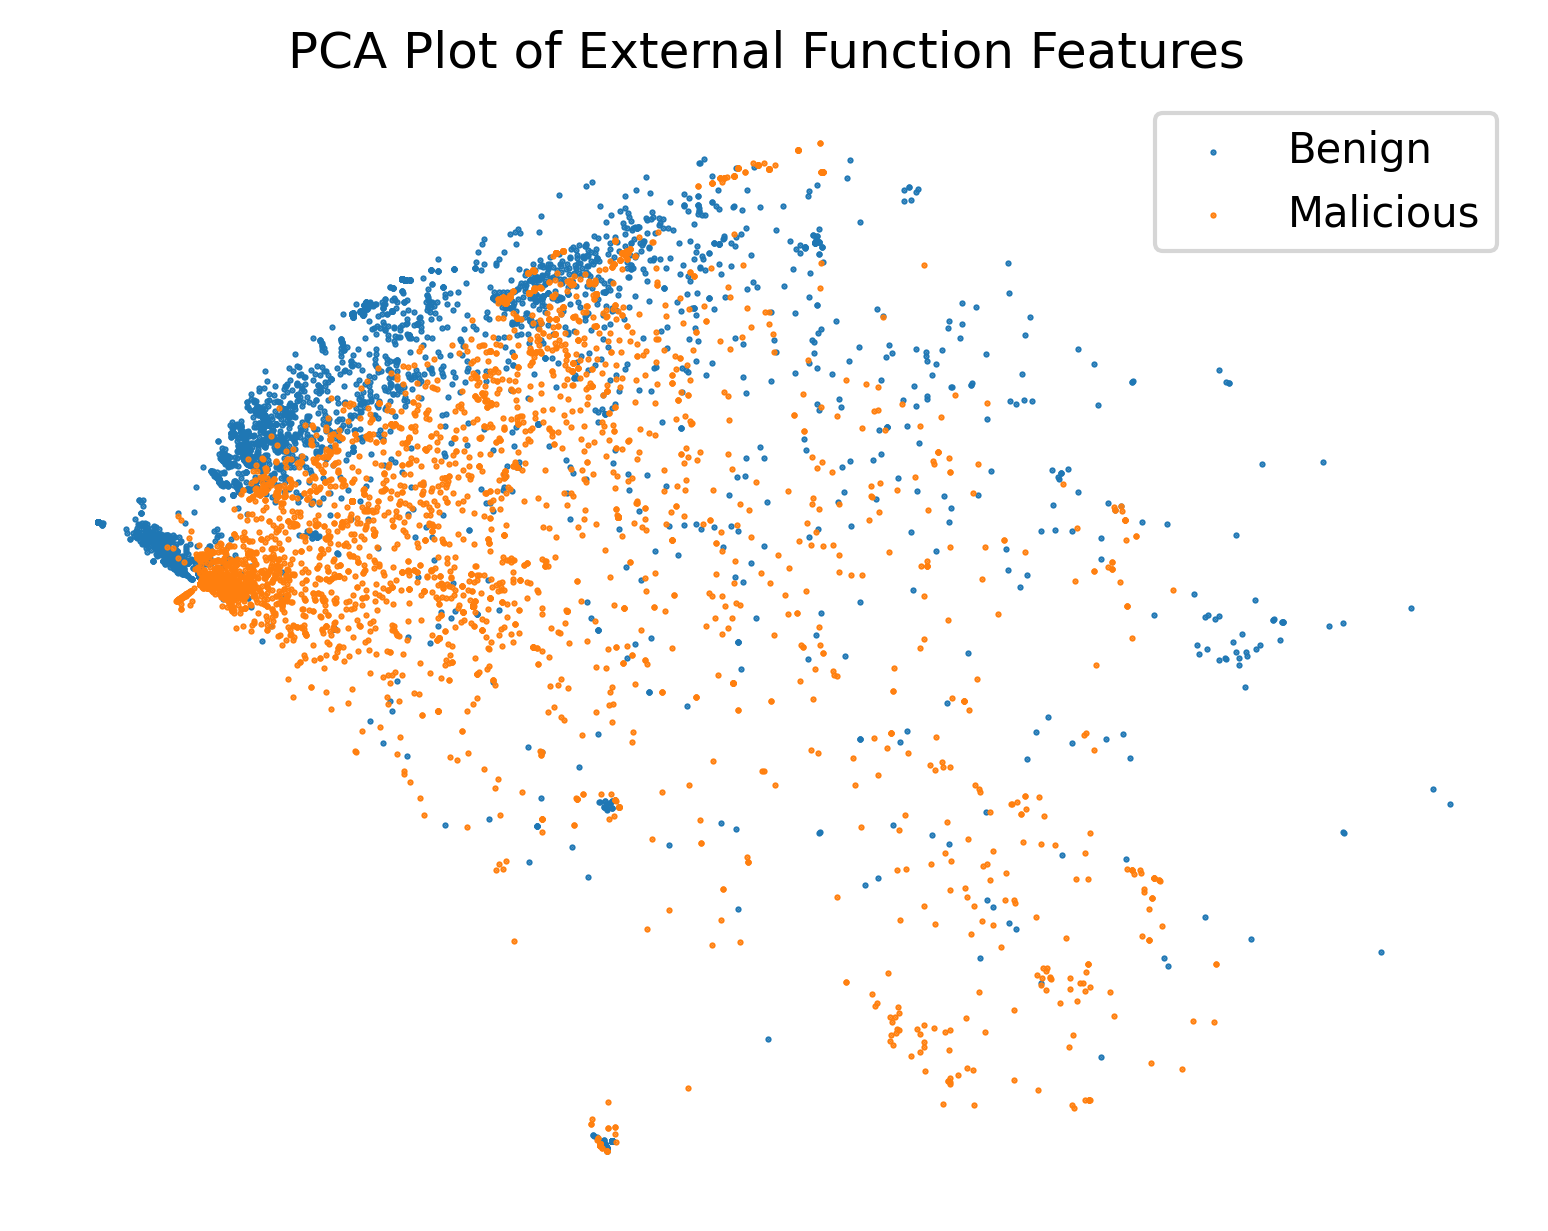

In [30]:
pca = PCA(n_components=2)
X_hat = pca.fit_transform(fn_matrix_processed)

plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("PCA Plot of External Function Features ")
plt.legend()
plt.show()

### MDS

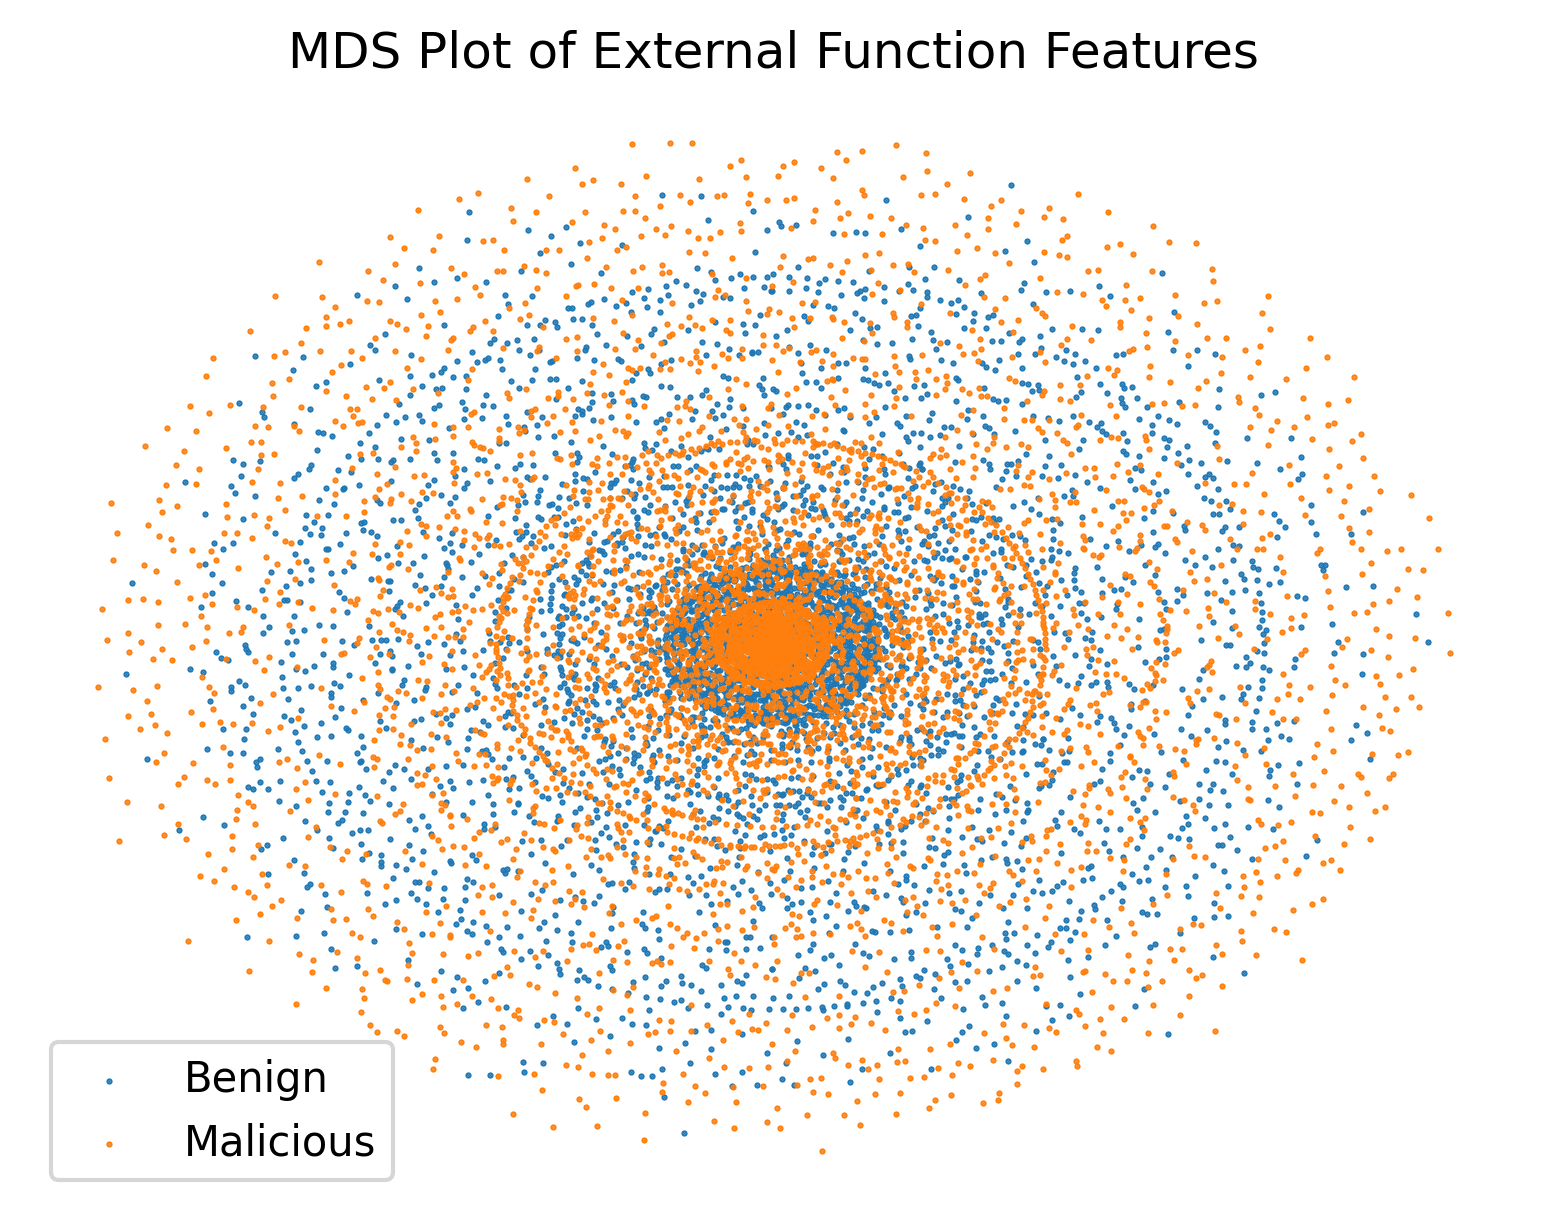

In [31]:
mds = MDS(dissimilarity="precomputed")
X_hat = mds.fit_transform(fn_sim)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("MDS Plot of External Function Features")
plt.legend()
plt.show()

### TSNE

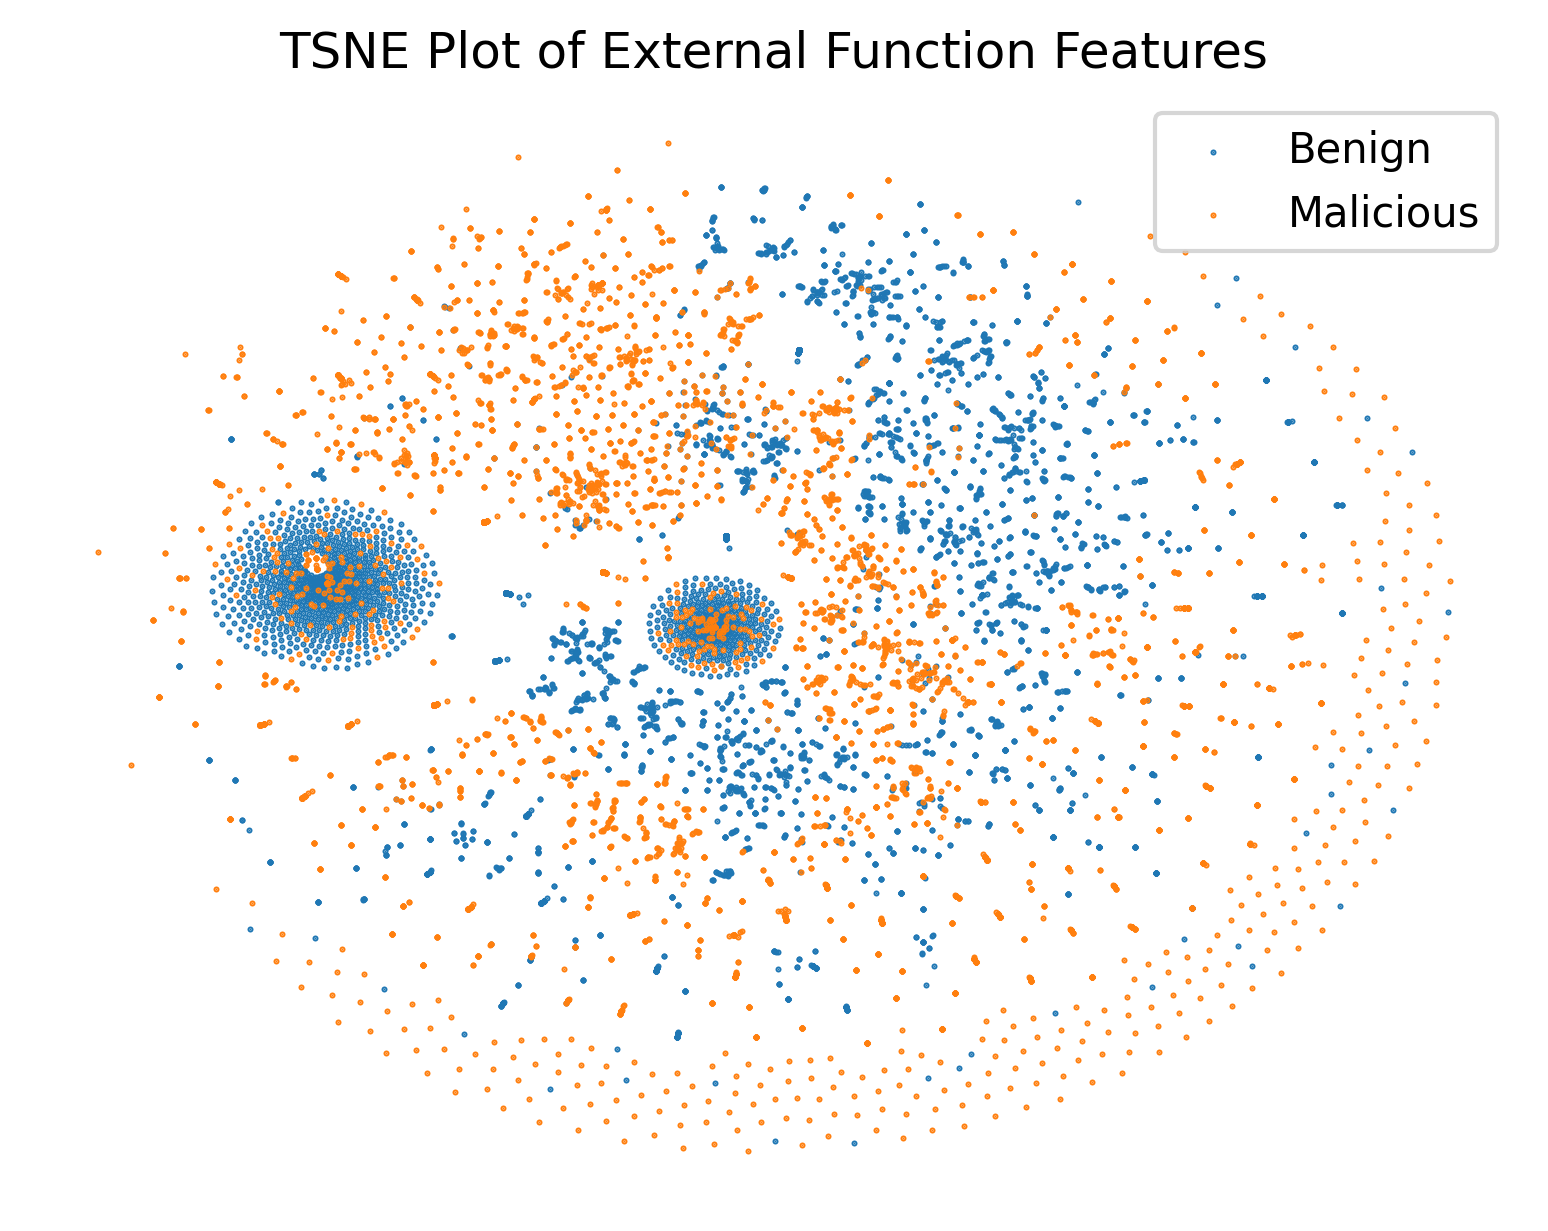

In [32]:
tsne = TSNE(n_components=2, learning_rate="auto", init="random", perplexity=3)
X_hat = tsne.fit_transform(fn_matrix)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.2)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.2)
plt.axis("off")
plt.legend()
plt.title("TSNE Plot of External Function Features")
plt.show()

## Characteristics

In [12]:
malicious_fns = [
    fn
    for program in imports["malicious"].keys()
    for fn in imports["malicious"][program]
]
malicious_fns_usage = Counter(malicious_fns)

benign_fns = [
    fn for program in imports["benign"].keys() for fn in imports["benign"][program]
]
benign_fns_usage = Counter(benign_fns)

### Malicious Functions

External functions which are only seen within malicious executables.  

In [13]:
only_mal = set(malicious_fns) - set(benign_fns)
print(f"{len(only_mal)} Functions only used in malicious binaries")
malicious_usage = {fn: malicious_fns_usage[fn] for fn in only_mal}
malicious_usage = dict(
    reversed(sorted(malicious_usage.items(), key=lambda item: item[1]))
)

pd.DataFrame(
    {
        "Function name": malicious_usage.keys(),
        "Number of occurrences": malicious_usage.values(),
        "Frequency": np.array(list(malicious_usage.values())) / n_mal,
    }
)

11701 Functions only used in malicious binaries

,Function name,Number of occurrences,Frequency
0,__vbaExceptHandler,423,0.073032
1,EVENT_SINK_QueryInterface,391,0.067507
2,EVENT_SINK_Release,391,0.067507
3,EVENT_SINK_AddRef,390,0.067334
4,DllFunctionCall,387,0.066816
...,...,...,...
11696,ScsiPortStallExecution,1,0.000173
11697,?OnIdle@CKitWinApp@@UAEHJ@Z,1,0.000173
11698,?SetPlaybackPosition@CDataCommsView@@QAEXH_N@Z,1,0.000173
11699,?SetFreezeFrameData@CFreezeFrameData_wThreshol...,1,0.000173


### Benign Functions

External functions which are only seen in benign executables. 

In [14]:
only_ben = set(benign_fns) - set(malicious_fns)
print(f"{len(only_ben)} Functions only used in benign binaries")
benign_usage = {fn: benign_fns_usage[fn] for fn in only_ben}
benign_usage = dict(reversed(sorted(benign_usage.items(), key=lambda item: item[1])))

pd.DataFrame(
    {
        "Function name": benign_usage.keys(),
        "Number of occurrences": benign_usage.values(),
        "Frequency": np.array(list(benign_usage.values())) / n_ben,
    }
)

58457 Functions only used in benign binaries

,Function name,Number of occurrences,Frequency
0,__C_specific_handler,1260,0.236709
1,RtlLookupFunctionEntry,1253,0.235394
2,RtlVirtualUnwind,1253,0.235394
3,_register_thread_local_exe_atexit_callback,756,0.142025
4,_crt_atexit,717,0.134698
...,...,...,...
58452,_ZN4llvm3opt14DerivedArgListC1ERKNS0_12InputAr...,1,0.000188
58453,Shell_InitReminders,1,0.000188
58454,?setNotchTarget@QDial@@QEAAXN@Z,1,0.000188
58455,execute_java_constructor_vararg,1,0.000188


### Overall

Functions seen in both classes of executable. 

In [40]:
both = set(benign_fns) & set(malicious_fns)
print(f"{len(both)} Functions seen in both classes across dataset")
sorted_usage = dict(
    {
        k: v
        for k, v in reversed(sorted(fn_usage.items(), key=lambda item: item[1]))
        if k in both
    }
)
mfns = [mal_fn for mal_fn in malicious_fns if mal_fn in both]
bfns = [ben_fn for ben_fn in benign_fns if ben_fn in both]

mfns_usage = {k: v for k, v in malicious_fns_usage.items() if k in mfns}
bfns_usage = {k: v for k, v in benign_fns_usage.items() if k in bfns}

mfns_usage = dict(
    reversed(sorted(mfns_usage.items(), key=lambda item: sorted_usage[item[0]]))
)
bfns_usage = dict(
    reversed(sorted(bfns_usage.items(), key=lambda item: sorted_usage[item[0]]))
)

5926 Functions seen in both classes across dataset

In [16]:
df = pd.DataFrame(
    {
        ("Function name", ""): sorted_usage.keys(),
        ("Occurances", "Total"): sorted_usage.values(),
        ("Occurances", "Malicious"): mfns_usage.values(),
        ("Occurances", "Benign"): bfns_usage.values(),
        ("Frequency", "Overall"): np.array(list(sorted_usage.values())) / len(dataset),
        ("Frequency", "Malicious"): np.array(list(mfns_usage.values())) / n_mal,
        ("Frequency", "Benign"): np.array(list(bfns_usage.values())) / n_ben,
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Function name Occurances                   \
                                                Total Malicious Benign   
0                           GetProcAddress       6936      4193   2743   
1                             GetLastError       6312      3373   2939   
2                        GetCurrentProcess       5515      2830   2685   
3                              CloseHandle       5476      3296   2180   
4                                    Sleep       5225      2831   2394   
...                                    ...        ...       ...    ...   
5921  ?id@?$numpunct@_W@std@@2V0locale@2@A          2         1      1   
5922                FindNextUrlCacheEntryW          2         1      1   
5923               FindFirstUrlCacheEntryW          2         1      1   
5924                               GetJobA          2         1      1   
5925                            glIndexubv          2         1      1   

     Frequency                      
       Overall Malicious    Benign  
0     0.624022  0.723930  0.515311  
1     0.567881  0.582355  0.552132  
2     0.496176  0.488605  0.504415  
3     0.492668  0.569061  0.409543  
4     0.470085  0.488778  0.449746  
...        ...       ...       ...  
5921  0.000180  0.000173  0.000188  
5922  0.000180  0.000173  0.000188  
5923  0.000180  0.000173  0.000188  
5924  0.000180  0.000173  0.000188  
5925  0.000180  0.000173  0.000188  

[5926 rows x 7 columns]

# DLL Analysis

## Feature Extraction

In [17]:
if PERFORM_EXTRACTION:
    dlls = {
        "malicious": {},
        "benign": {},
    }
    for path, label in tqdm(dataset, total=len(dataset)):
        exec_dlls = get_dlls(path)
        dlls["malicious" if label == 1 else "benign"][path.split("/")[-1]] = exec_dlls
    json.dump(dlls, open("dataset-dlls.json", "w"))
else:
    dlls = json.loads(open("dataset-dlls.json", "r").read())

In [18]:
dll_usage = Counter(
    [dll for cat in dlls for apis in dlls[cat].values() for dll in apis]
)
dlls_used = list(dll_usage.keys())

In [19]:
dll_matrix = np.zeros((len(dataset), len(dlls_used)))
i = 0
for cat in dlls:
    for program in dlls[cat].keys():
        for j, dll in enumerate(dlls_used):
            if dll in dlls[cat][program]:
                dll_matrix[i, j] = 1
        i += 1

In [20]:
dll_matrix_processed = dll_matrix.copy()

if SHUFFLE:
    np.random.shuffle(dll_matrix_processed[:n_mal])
    np.random.shuffle(dll_matrix_processed[n_mal:])

## Similarity 

In [21]:
dll_sim = cosine_similarity(dll_matrix_processed)

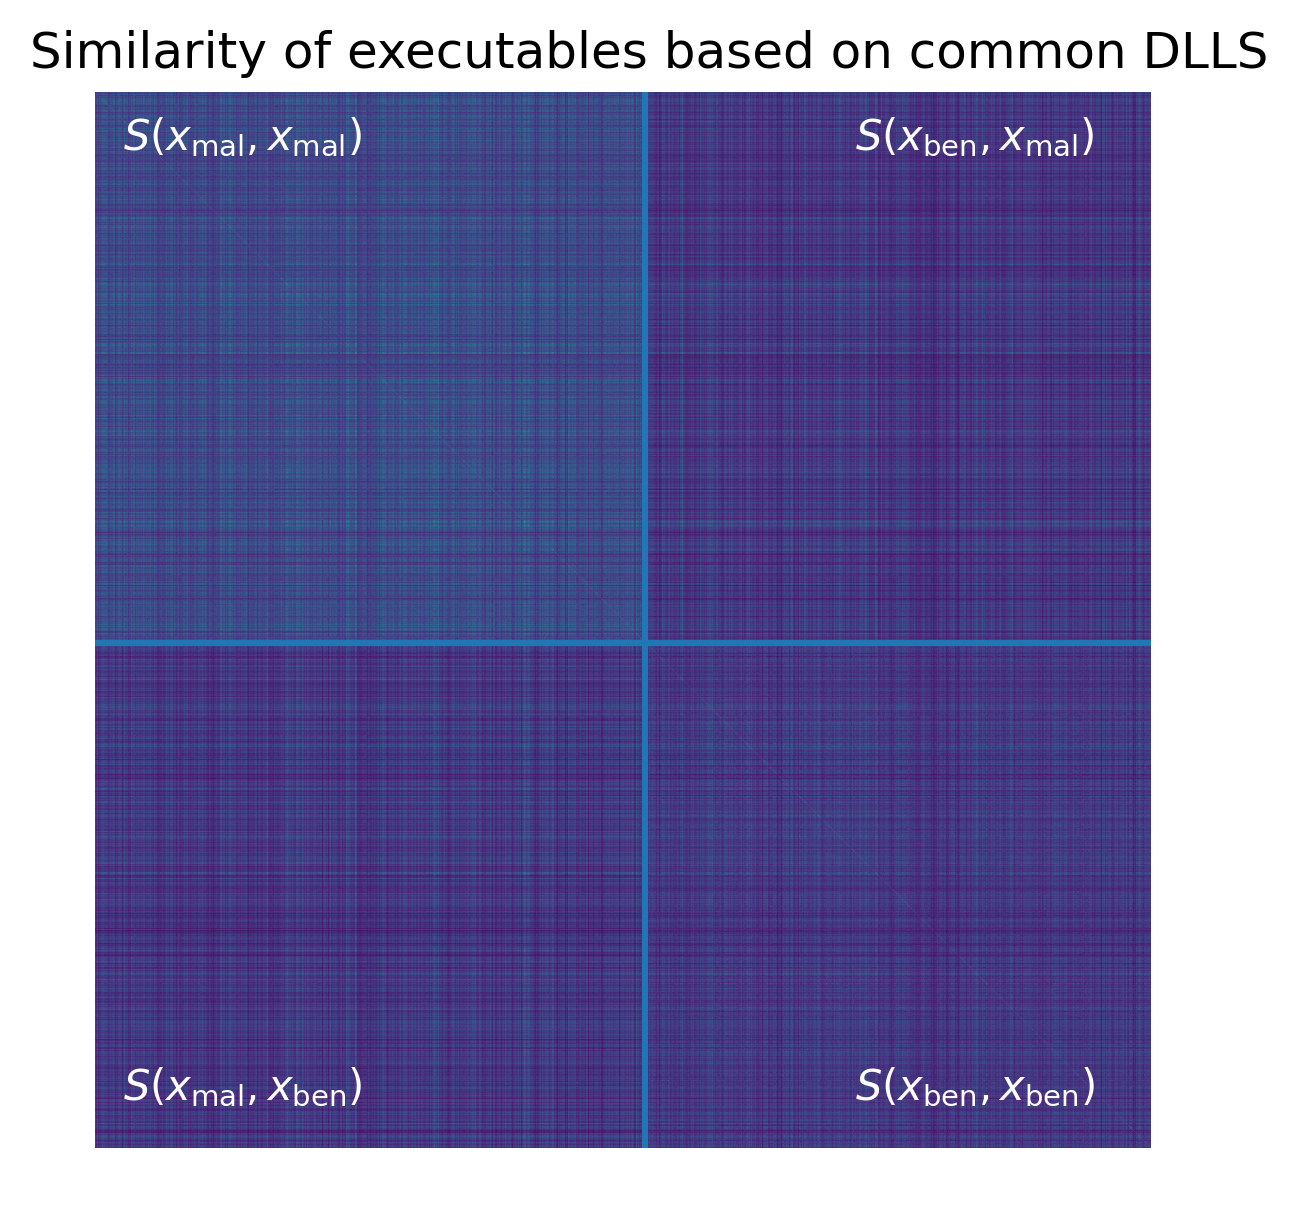

In [22]:
plt.imshow(dll_sim)
plt.axis("off")
plt.title("Similarity of executables based on common DLLS")
plt.hlines(np.count_nonzero(labels), 0, len(dataset))
plt.vlines(np.count_nonzero(labels), 0, len(dataset))
plt.text(300, 600, r"$S(x_\text{mal}, x_\text{mal})$", c="white")
plt.text(300, 10600, r"$S(x_\text{mal}, x_\text{ben})$", c="white")
plt.text(8000, 10600, r"$S(x_\text{ben}, x_\text{ben})$", c="white")
plt.text(8000, 600, r"$S(x_\text{ben}, x_\text{mal})$", c="white")
plt.show()

In [23]:
most_similar = find_most_similar(dll_sim)
sim = dll_sim[most_similar[:, 0], most_similar[:, 1]]

df = pd.DataFrame(
    {
        ("Similarity", ""): sim,
        ("Programs", "1"): programs[most_similar[:, 0]],
        ("Programs", "2"): programs[most_similar[:, 1]],
    }
)
df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Similarity                                     Programs  \
                                                        1   
0        1.0                                 web-page.exe   
1        1.0  VirusShare_1cc953d4a293abddbd77534b713c81c0   
2        1.0  VirusShare_55d35581cfa0538745dbbcb01488fc40   
3        1.0  VirusShare_1f22d2c2b93ea2845ce8c8c6dc98df40   
4        1.0  VirusShare_3b9d9de31c7560b385d40af1eb049e30   
5        1.0  VirusShare_3a077b554f360c4c275a5ae259e7b410   
6        1.0  VirusShare_3b9d9de31c7560b385d40af1eb049e30   
7        1.0  VirusShare_55d35581cfa0538745dbbcb01488fc40   
8        1.0  VirusShare_566bee9bc9356594218bd5fe80f2e4f6   
9        1.0  VirusShare_56af0b35bc7613191fc40f120a41b840   

                                                
                                             2  
0                  PowerToys.ShortcutGuide.exe  
1  VirusShare_1c8e95e900a3d2c32575278a79aab7a8  
2  VirusShare_563c995814400b5938541e597aab5955  
3  VirusShare_1d5524c515c1c9012b75762ae3e6dee0  
4  VirusShare_574745d9f8f09c4bc2c5ede18182adfc  
5  VirusShare_55d35581cfa0538745dbbcb01488fc40  
6  VirusShare_2c44df649b535a4308d48e4160cdb168  
7  VirusShare_0341ffb609c6d2fa0f9f6bb9df432540  
8  VirusShare_2d33b1b71d4d595417e9f2520233623b  
9  VirusShare_563c995814400b5938541e597aab5955

In [24]:
print(
    f"Average similarity of malicious samples: {np.mean(dll_sim[:n_mal, :n_mal]):.4f}"
)
print(
    f"Average similarity of malicious and benign samples: {np.mean(dll_sim[n_mal:, :n_mal]):.4f}"
)
print(f"Average similarity of benign samples: {np.mean(dll_sim[n_mal:, n_mal:]):.4f}")

Average similarity of malicious samples: 0.2249

Average similarity of malicious and benign samples: 0.1606

Average similarity of benign samples: 0.1643

## Visualisation 

### PCA

In [33]:
pca = PCA(n_components=2)
X_hat = pca.fit_transform(dll_matrix_processed)

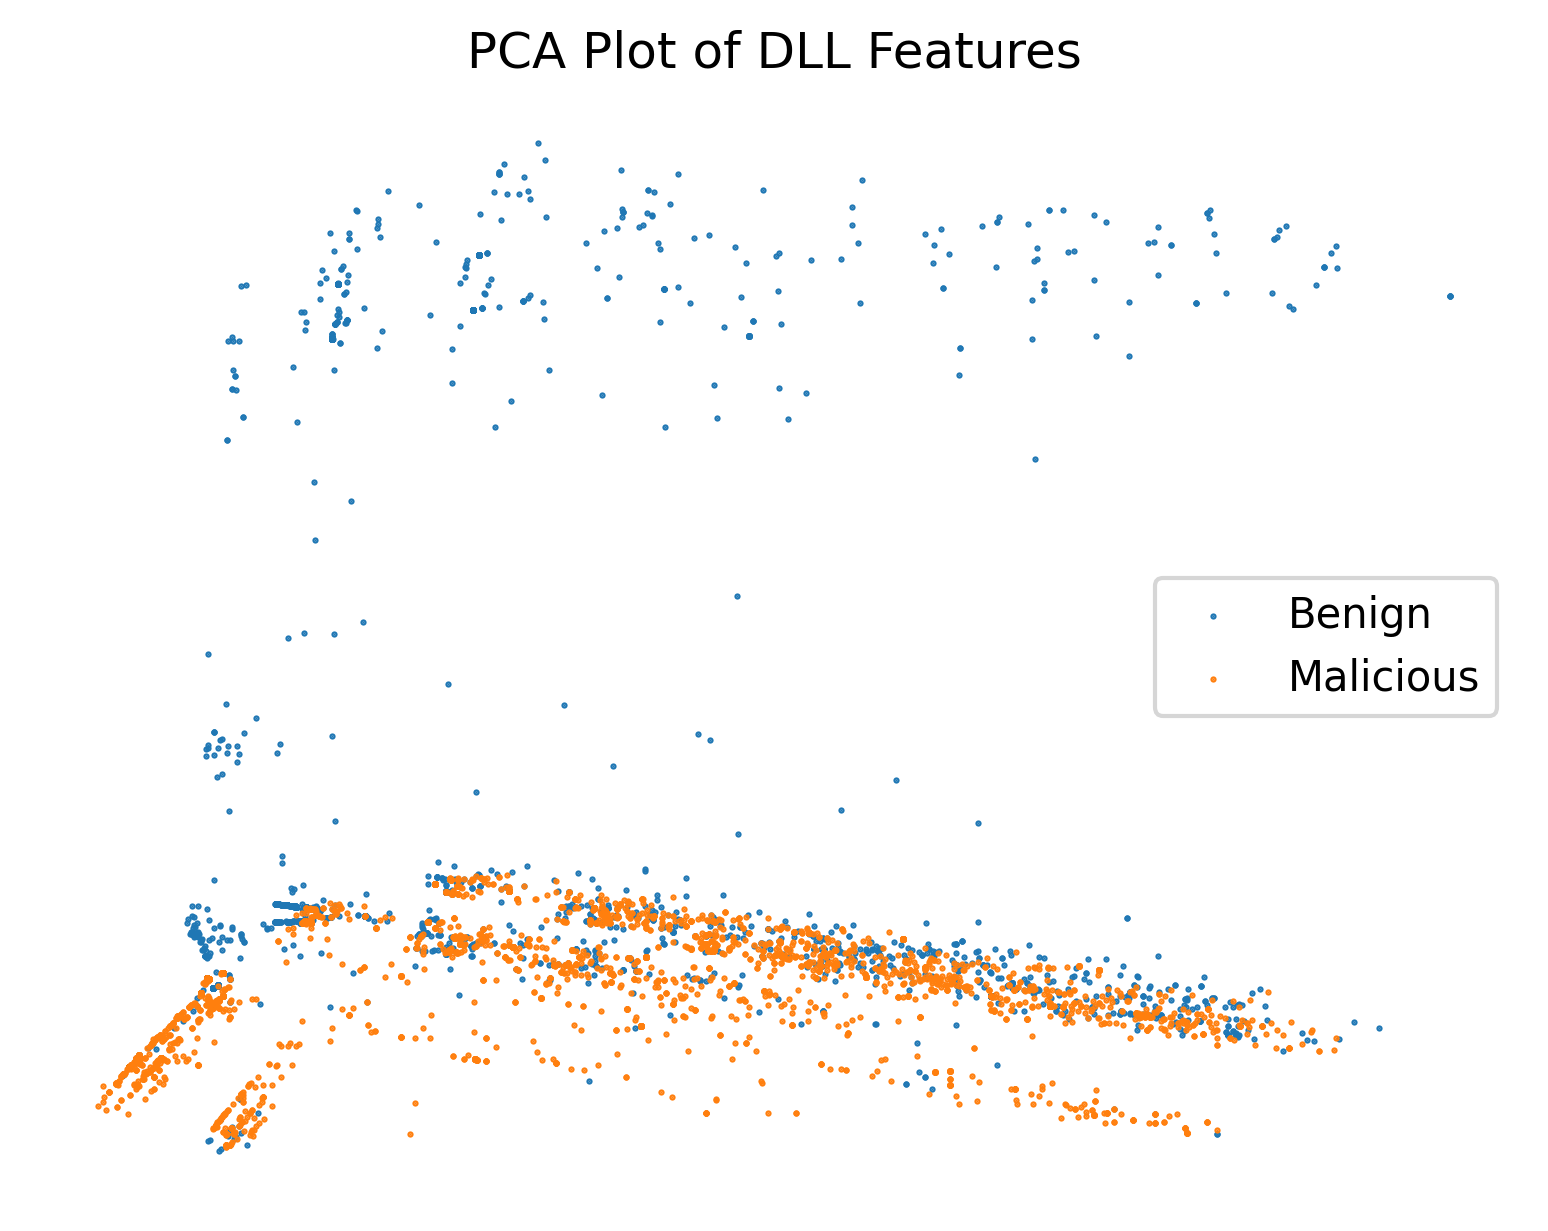

In [34]:
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("PCA Plot of DLL Features")
plt.legend()
plt.show()

### MDS

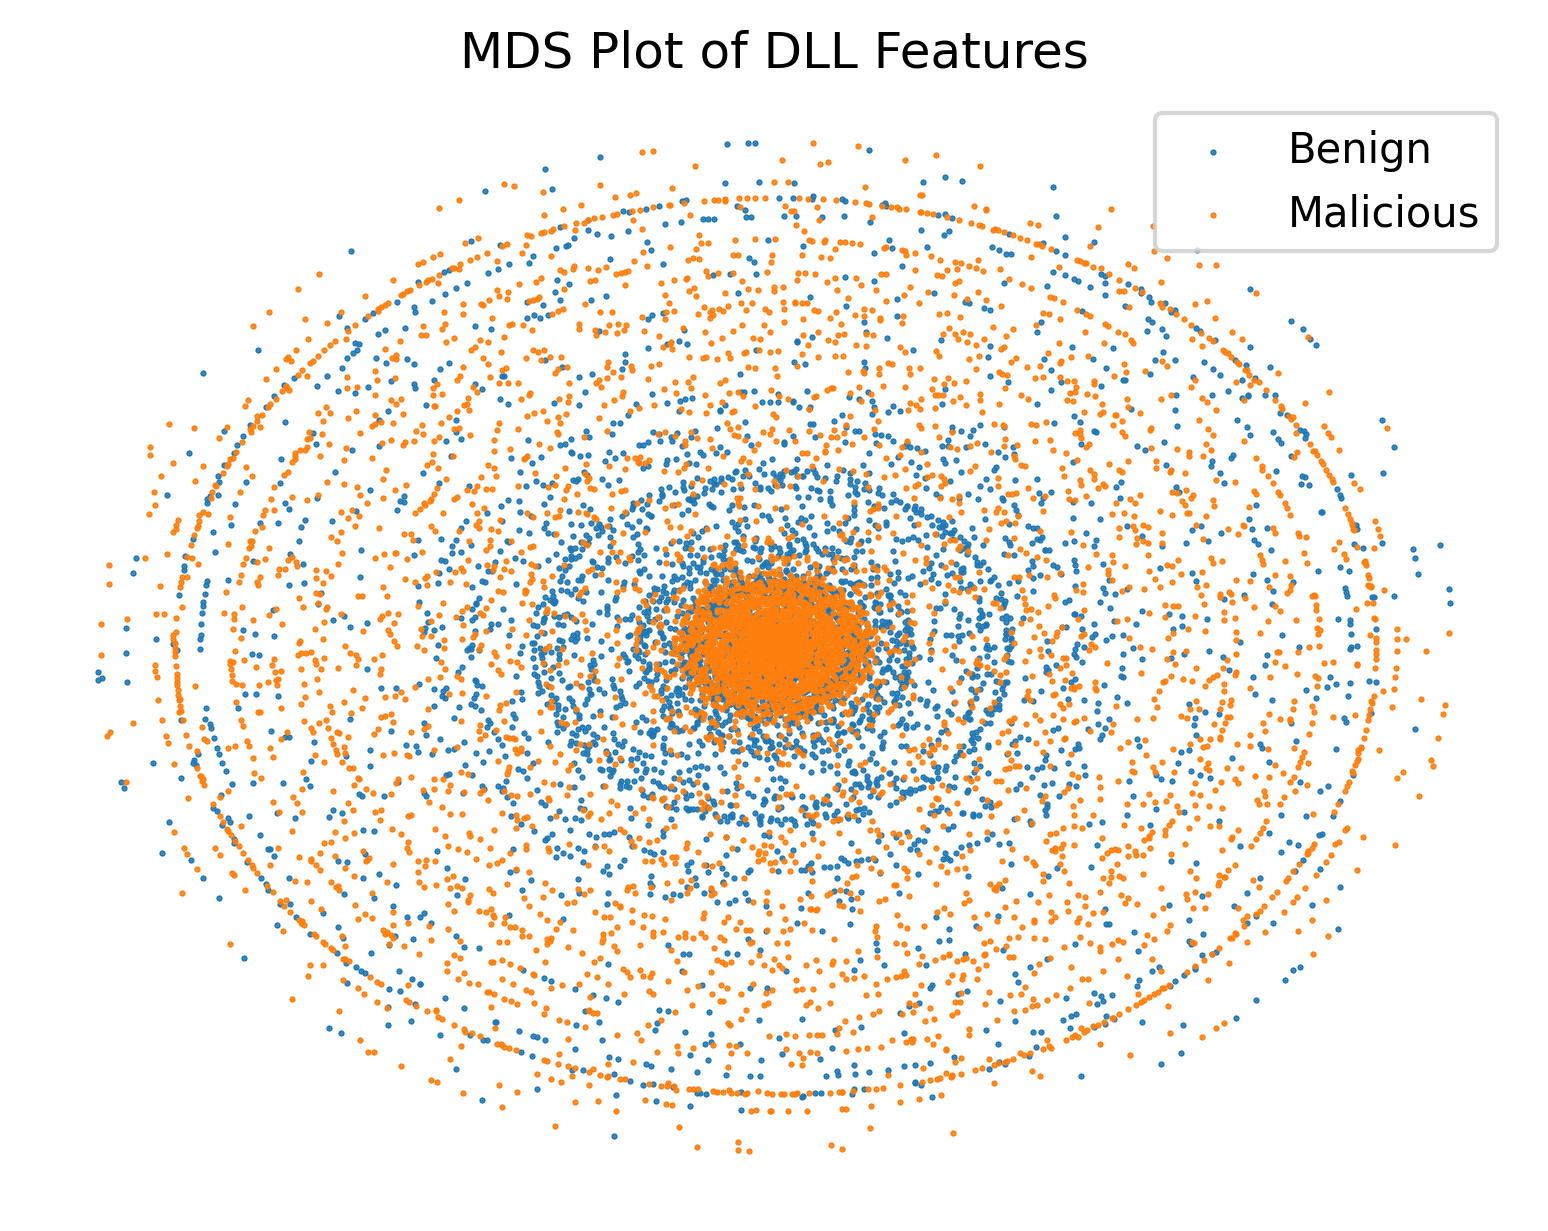

In [35]:
mds = MDS(dissimilarity="precomputed")
X_hat = mds.fit_transform(dll_sim)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("MDS Plot of DLL Features")
plt.legend()
plt.show()

### TSNE

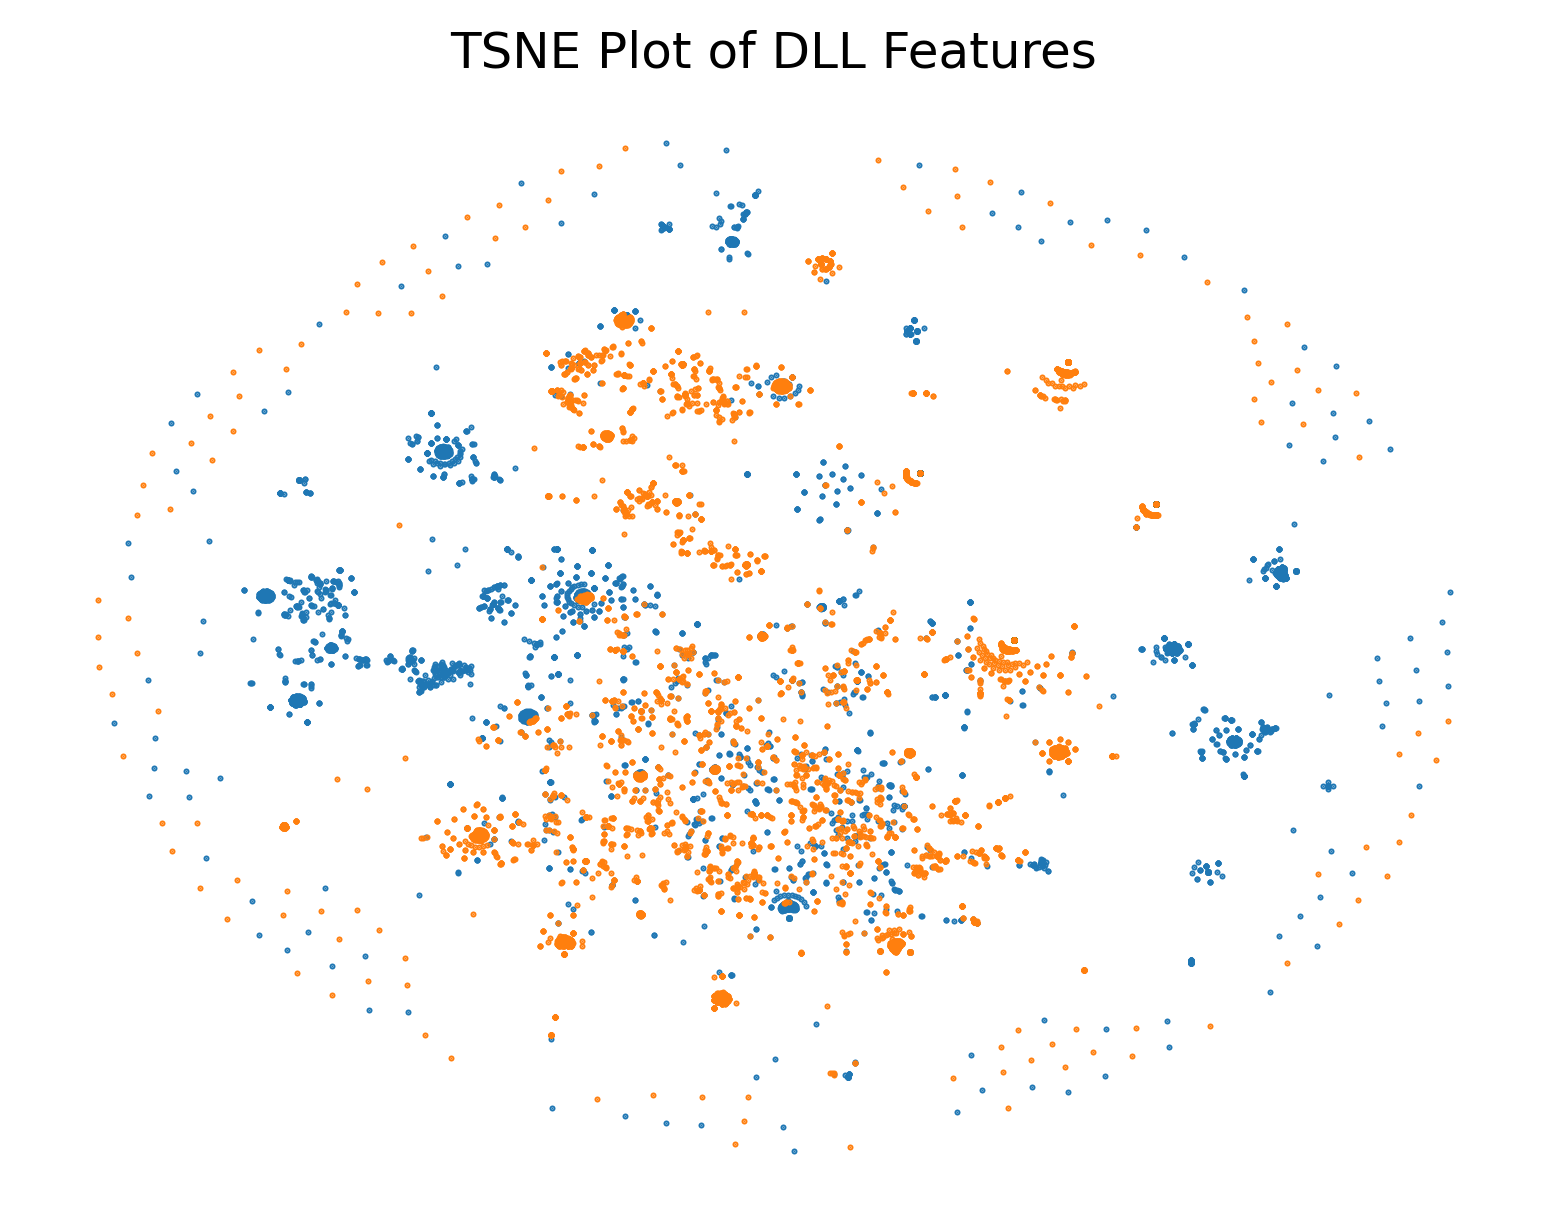

In [36]:
tsne = TSNE(n_components=2, learning_rate="auto", init="random")
X_hat = tsne.fit_transform(dll_matrix)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.2)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.2)
plt.axis("off")
plt.title("TSNE Plot of DLL Features")
plt.show()

## Characteristics

In [25]:
malicious_dlls = [
    dll for program in dlls["malicious"].keys() for dll in dlls["malicious"][program]
]
malicious_dlls_usage = Counter(malicious_dlls)

benign_dlls = [
    dll for program in dlls["benign"].keys() for dll in dlls["benign"][program]
]
benign_dlls_usage = Counter(benign_dlls)

### Malicious DLLs

In [26]:
only_mal = set(malicious_dlls) - set(benign_dlls)
print(f"{len(only_mal)} DLLs only seen in malicious binaries")
malicious_usage = {dll: malicious_dlls_usage[dll] for dll in only_mal}
malicious_usage = dict(
    reversed(sorted(malicious_usage.items(), key=lambda item: item[1]))
)

pd.DataFrame(
    {
        "DLL name": malicious_usage.keys(),
        "Number of occurrences": malicious_usage.values(),
        "Frequency": np.array(list(malicious_usage.values())) / n_mal,
    }
)

579 DLLs only seen in malicious binaries

,DLL name,Number of occurrences,Frequency
0,MSVBVM60.DLL,457,0.078902
1,AIMP2.dll,97,0.016747
2,MSVCP60.dll,58,0.010014
3,iMap.bpl,48,0.008287
4,URLMON.DLL,44,0.007597
...,...,...,...
574,cbx_lpm_add_sub.dll,1,0.000173
575,NTOSKRNL.exe,1,0.000173
576,printui.dll,1,0.000173
577,shLWaPi.Dll,1,0.000173


### Benign DLLs

In [27]:
only_ben = set(benign_dlls) - set(malicious_dlls)
print(f"{len(only_ben)} DLLs only seen in benign binaries")
benign_usage = {dll: benign_dlls_usage[dll] for dll in only_ben}
benign_usage = dict(reversed(sorted(benign_usage.items(), key=lambda item: item[1])))

pd.DataFrame(
    {
        "DLL name": benign_usage.keys(),
        "Number of occurrences": benign_usage.values(),
        "Frequency": np.array(list(benign_usage.values())) / n_ben,
    }
)

1031 DLLs only seen in benign binaries

,DLL name,Number of occurrences,Frequency
0,api-ms-win-crt-runtime-l1-1-0.dll,750,0.140898
1,api-ms-win-crt-locale-l1-1-0.dll,718,0.134886
2,api-ms-win-crt-heap-l1-1-0.dll,711,0.133571
3,api-ms-win-crt-math-l1-1-0.dll,711,0.133571
4,api-ms-win-crt-stdio-l1-1-0.dll,709,0.133196
...,...,...,...
1026,mingw-get-0.dll,1,0.000188
1027,api-ms-win-shcore-registry-l1-1-0.dll,1,0.000188
1028,libmonosgen-2.0.dll,1,0.000188
1029,wxmsw311u_html_vc_custom.dll,1,0.000188


### Overall

In [28]:
both = set(benign_dlls) & set(malicious_dlls)
print(f"{len(both)} DLLs seen in both classes across dataset")
sorted_usage = dict(
    {
        k: v
        for k, v in reversed(sorted(dll_usage.items(), key=lambda item: item[1]))
        if k in both
    }
)
m_dlls = [mal_dll for mal_dll in malicious_dlls if mal_dll in both]
b_dlls = [ben_dll for ben_dll in benign_dlls if ben_dll in both]

m_dll_usage = {k: v for k, v in malicious_dlls_usage.items() if k in m_dlls}
b_dll_usage = {k: v for k, v in benign_dlls_usage.items() if k in b_dlls}

m_dll_usage = dict(
    reversed(sorted(m_dll_usage.items(), key=lambda item: sorted_usage[item[0]]))
)
b_dll_usage = dict(
    reversed(sorted(b_dll_usage.items(), key=lambda item: sorted_usage[item[0]]))
)

196 DLLs seen in both classes across dataset

In [29]:
df = pd.DataFrame(
    {
        ("DLL name", ""): sorted_usage.keys(),
        ("Occurrences", "Total"): sorted_usage.values(),
        ("Occurrences", "Malicious"): m_dll_usage.values(),
        ("Occurrences", "Benign"): b_dll_usage.values(),
        ("Frequency", "Overall"): np.array(list(sorted_usage.values())) / len(dataset),
        ("Frequency", "Malicious"): np.array(list(m_dll_usage.values())) / n_mal,
        ("Frequency", "Benign"): np.array(list(b_dll_usage.values())) / n_ben,
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
df

DLL name Occurrences                  Frequency                    
                        Total Malicious Benign   Overall Malicious    Benign
0    KERNEL32.dll        7360      3649   3711  0.662168  0.630007  0.697163
1      USER32.dll        3966      2712   1254  0.356815  0.468232  0.235581
2    ADVAPI32.dll        3831      2364   1467  0.344669  0.408149  0.275596
3     SHELL32.dll        2376      1468    908  0.213765  0.253453  0.170580
4       ole32.dll        2343      1577    766  0.210796  0.272272  0.143904
..            ...         ...       ...    ...       ...       ...       ...
191   TRAFFIC.dll           2         1      1  0.000180  0.000173  0.000188
192  bthprops.cpl           2         1      1  0.000180  0.000173  0.000188
193    QUARTZ.dll           2         1      1  0.000180  0.000173  0.000188
194    dbgeng.dll           2         1      1  0.000180  0.000173  0.000188
195       STI.dll           2         1      1  0.000180  0.000173  0.000188

[196 rows x 7 columns]